In [19]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/salonigupta16/trader-data-csv/trader_data.csv.csv
/kaggle/input/datasets/salonigupta16/sentiment-csv/sentiment.csv.csv


In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os


sns.set_theme(style="whitegrid")


sentiment_path = '/kaggle/input/datasets/salonigupta16/sentiment-csv/sentiment.csv.csv'
trader_path = '/kaggle/input/datasets/salonigupta16/trader-data-csv/trader_data.csv.csv'

df_sentiment = pd.read_csv(sentiment_path)
df_trader = pd.read_csv(trader_path)


print(f"Sentiment Data: {df_sentiment.shape[0]} rows, {df_sentiment.shape[1]} columns")
print(f"Trader Data: {df_trader.shape[0]} rows, {df_trader.shape[1]} columns")

print("\nMissing Values:")
print("Sentiment:\n", df_sentiment.isnull().sum())
print("\nTrader Data:\n", df_trader.isnull().sum())

print("\nDuplicates:")
print(f"Sentiment: {df_sentiment.duplicated().sum()}, Trader: {df_trader.duplicated().sum()}")

Sentiment Data: 2644 rows, 4 columns
Trader Data: 211224 rows, 16 columns

Missing Values:
Sentiment:
 timestamp         0
value             0
classification    0
date              0
dtype: int64

Trader Data:
 Account             0
Coin                0
Execution Price     0
Size Tokens         0
Size USD            0
Side                0
Timestamp IST       0
Start Position      0
Direction           0
Closed PnL          0
Transaction Hash    0
Order ID            0
Crossed             0
Fee                 0
Trade ID            0
Timestamp           0
dtype: int64

Duplicates:
Sentiment: 0, Trader: 0


In [21]:

print("Sentiment columns:", df_sentiment.columns.tolist())
print("Trader columns:", df_trader.columns.tolist())

Sentiment columns: ['timestamp', 'value', 'classification', 'date']
Trader columns: ['Account', 'Coin', 'Execution Price', 'Size Tokens', 'Size USD', 'Side', 'Timestamp IST', 'Start Position', 'Direction', 'Closed PnL', 'Transaction Hash', 'Order ID', 'Crossed', 'Fee', 'Trade ID', 'Timestamp']


In [22]:

df_sentiment['date'] = pd.to_datetime(df_sentiment['date']).dt.date

df_trader['datetime'] = pd.to_datetime(df_trader['Timestamp'], unit='ms')
df_trader['date'] = df_trader['datetime'].dt.date


df_merged = pd.merge(df_trader, df_sentiment, on='date', how='inner')


df_merged.head()

,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,...,Order ID,Crossed,Fee,Trade ID,Timestamp,datetime,date,timestamp,value,classification
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,02-12-2024 22:50,0.000000,Buy,0.0,...,52017706630,True,0.345404,8.950000e+14,1.730000e+12,2024-10-27 03:33:20,2024-10-27,1730007000,74,Greed
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,02-12-2024 22:50,986.524596,Buy,0.0,...,52017706630,True,0.005600,4.430000e+14,1.730000e+12,2024-10-27 03:33:20,2024-10-27,1730007000,74,Greed
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,02-12-2024 22:50,1002.518996,Buy,0.0,...,52017706630,True,0.050431,6.600000e+14,1.730000e+12,2024-10-27 03:33:20,2024-10-27,1730007000,74,Greed
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,02-12-2024 22:50,1146.558564,Buy,0.0,...,52017706630,True,0.050043,1.080000e+15,1.730000e+12,2024-10-27 03:33:20,2024-10-27,1730007000,74,Greed
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,02-12-2024 22:50,1289.488521,Buy,0.0,...,52017706630,True,0.003055,1.050000e+15,1.730000e+12,2024-10-27 03:33:20,2024-10-27,1730007000,74,Greed


In [23]:

df_merged['is_win'] = df_merged['Closed PnL'] > 0


daily_metrics = df_merged.groupby(['date', 'Account', 'classification']).agg(
    daily_PnL=('Closed PnL', 'sum'),
    trade_count=('Account', 'count'),
    win_rate=('is_win', 'mean'),
    avg_trade_size=('Size USD', 'mean') 
    
).reset_index()


daily_metrics.head()

,date,Account,classification,daily_PnL,trade_count,win_rate,avg_trade_size
0,2023-03-28,0x3998f134d6aaa2b6a5f723806d00fd2bbbbce891,Greed,0.000000,3,0.000000,159.000000
1,2023-11-14,0x3998f134d6aaa2b6a5f723806d00fd2bbbbce891,Greed,0.000000,2,0.000000,23066.935000
2,2023-11-14,0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23,Greed,155.503357,1043,0.275168,11034.799511
3,2024-03-09,0x3998f134d6aaa2b6a5f723806d00fd2bbbbce891,Extreme Greed,-5564.016140,27,0.333333,3048.594444
4,2024-03-09,0x430f09841d65beb3f27765503d0f850b8bce7713,Extreme Greed,0.000000,88,0.000000,1136.312727


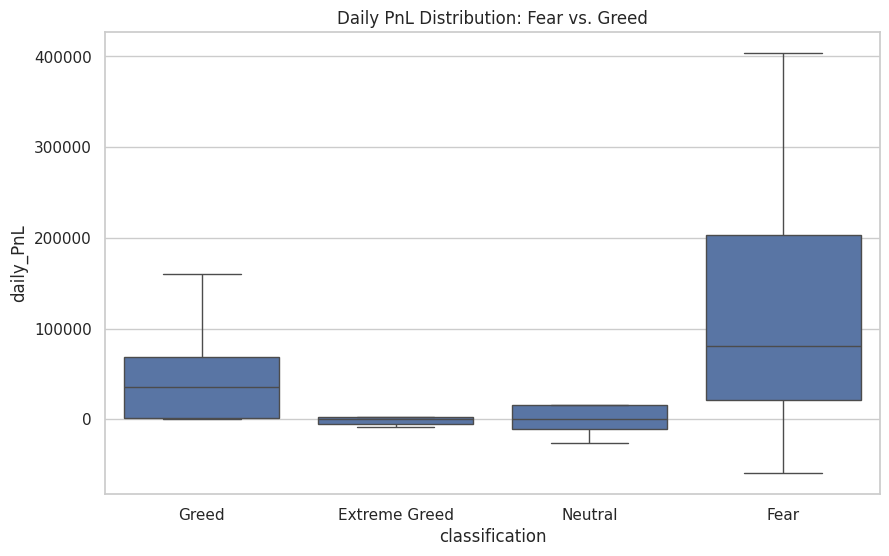

In [24]:

plt.figure(figsize=(10, 6))


sns.boxplot(data=daily_metrics, x='classification', y='daily_PnL', showfliers=False) 


plt.title('Daily PnL Distribution: Fear vs. Greed')
plt.show()

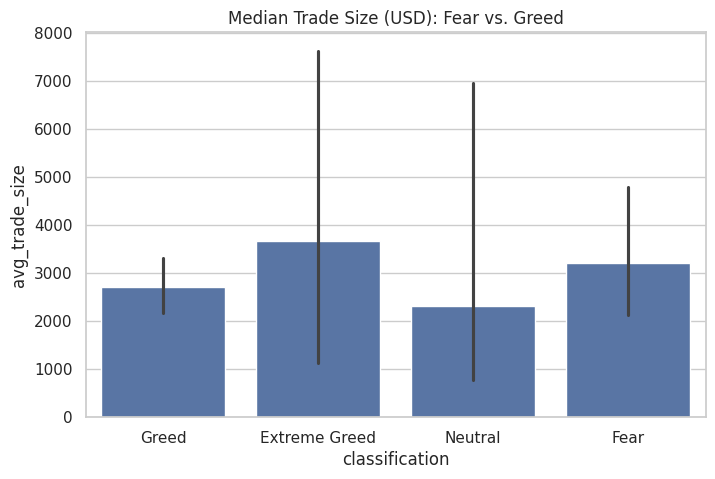

In [25]:

plt.figure(figsize=(8, 5))


sns.barplot(data=daily_metrics, x='classification', y='avg_trade_size', estimator=np.median)

plt.title('Median Trade Size (USD): Fear vs. Greed')
plt.show()

<Axes: xlabel='classification', ylabel='daily_PnL'>

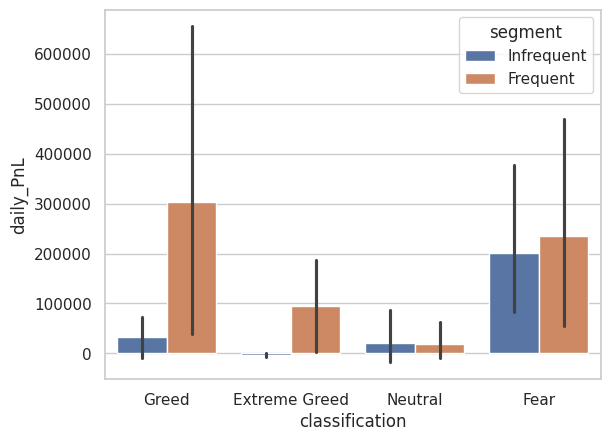

In [26]:

trader_totals = df_merged.groupby('Account').agg(total_trades=('Account', 'count'))


threshold = trader_totals['total_trades'].quantile(0.75)
trader_totals['segment'] = np.where(trader_totals['total_trades'] > threshold, 'Frequent', 'Infrequent')


daily_metrics = daily_metrics.merge(trader_totals[['segment']], left_on='Account', right_index=True)


sns.barplot(data=daily_metrics, x='classification', y='daily_PnL', hue='segment')